# Машинное обучение 1, ПМИ ФКН ВШЭ
# Семинар 12

## Обучение без учителя: кластеризация

**Кластеризация** - это метод машинного обучения, направленный на группировку объектов в пространстве признаков таким образом, чтобы точки внутри одной группы были похожи друг на друга, а точки из разных групп - существенно различались.

Кластеризация относится к методам обучения без учителя и является одним из базовых инструментов статистического анализа данных. Она находит применение во множестве областей - от построения портретов пользователей и сегментации клиентов до поиска аномалий и анализа поведения.  
В задачах анализа данных кластеризация позволяет выявлять скрытые закономерности и структуру, наблюдая, каким образом объекты объединяются в группы.


# Постановка задачи

Представим, что международное круизное агентство "Carnival Cruise Line" решило себя разрекламировать с помощью баннеров и обратилось для этого к вам. Чтобы протестировать, велика ли от таких баннеров польза, их будет размещено всего 20 штук по всему миру. Вам надо выбрать 20 таких локаций для размещения, чтобы польза была большой, и агентство продолжило с вами сотрудничать.

Агентство крупное, и у него есть офисы по всему миру. Вблизи этих офисов оно и хочет разместить баннеры (легче договариваться и проверять результат). Также эти места должны хорошо просматриваться. Ваша задача &mdash; найти подходящие места.

__Задание:__ Подумайте как бы вы решали эту задачу. Откуда бы вы взяли данные и какие?

> __Сначала подумайте, а после читайте блокнот дальше. Там спойлеры...__


## Ход мыслей

Примерный ход ваших рассуждений мог бы быть такой:

- Баннеры должны максимально привлекать внимание; для этого их стоит размещать в местах с высоким пешеходным трафиком и хорошей видимостью.
- Как найти скопления потенциальных путешественников? По геолокации - нужны данные о чекинах/посещениях (check-ins).
- На основе этих данных можно выполнить кластеризацию точек посещений, выделить наиболее популярные места в окрестности каждого офиса и предложить именно там расположить баннеры.


# Данные

Для поиска оптимальных мест воспользуемся базой данных крупнейшей социальной сети, основанной на локациях &mdash; Foursqare. Часть открытых данных есть, например, на сайте [archive.org.](https://archive.org/details/201309_foursquare_dataset_umn) Посмотрим на данные.

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Скачиваем данные посещений (чекинов)

In [1]:
!wget https://raw.githubusercontent.com/FUlyankin/ML_for_marketing/master/drafts/sem9_clasters/hw6/checkins.csv

--2026-06-05 02:08:05--  https://raw.githubusercontent.com/FUlyankin/ML_for_marketing/master/drafts/sem9_clasters/hw6/checkins.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28779325 (27M) [text/plain]
Saving to: ‘checkins.csv’

checkins.csv        100%[===================>]  27.45M  1.24MB/s    in 21s     

2026-06-05 02:08:27 (1.31 MB/s) - ‘checkins.csv’ saved [28779325/28779325]



In [ ]:
df = pd.read_csv('checkins.csv')
print(f'Размер выборки: {df.shape}')
df.head()

Размер выборки: (396634, 6)


,id,user_id,venue_id,latitude,longitude,created_at
0,984222,15824.0,5222.0,38.895112,-77.036366,2012-04-21 17:43:47
1,984234,44652.0,5222.0,33.800745,-84.410520,2012-04-21 17:43:43
2,984291,105054.0,5222.0,45.523452,-122.676207,2012-04-21 17:39:22
3,984318,2146539.0,5222.0,40.764462,-111.904565,2012-04-21 17:35:46
4,984232,93870.0,380645.0,33.448377,-112.074037,2012-04-21 17:38:18


- `id` &mdash; id наблюдения
- `user_id` &mdash; id пользователя в социальной сетке
- `venue_id` &mdash; id места, где произошёл чекин (рестораны, достопримечательности и тп)
- `latitude, longitude` &mdash; координаты чекина
- `created_at` &mdash; время чекина

Будем работать с сэмплом в $100000$ наблюдений.

In [ ]:
X_adv = df[['longitude', 'latitude']].sample(n=100_000, random_state=42).values
X_adv

array([[ -93.2982799,   44.840798 ],
       [ -77.0363658,   38.8951118],
       [-112.0740373,   33.4483771],
       ...,
       [-122.3320708,   47.6062095],
       [-120.6596156,   35.2827524],
       [-118.2436849,   34.0522342]])

Как мы помним, 20 баннеров надо разместить около офисов компании. Если воспользоваться Google Maps, можно узнать координаты этих офисов.

```
33.751277, -118.188740 (Los Angeles)
25.867736, -80.324116 (Miami)
51.503016, -0.075479 (London)
52.378894, 4.885084 (Amsterdam)
39.366487, 117.036146 (Beijing)
-33.868457, 151.205134 (Sydney)
```

In [ ]:
offices = np.array([
    [-118.188740,  33.751277],  # Los Angeles
    [ -80.324116,  25.867736],  # Miami
    [  -0.075479,  51.503016],  # London
    [   4.885084,  52.378894],  # Amsterdam
    [ 117.036146,  39.366487],  # Beijing
    [ 151.205134, -33.868457]   # Sydney
])

Посмотрим как расположение офисов и чекинов выглядит на картинке и попробуем догадаться, где какой материк.

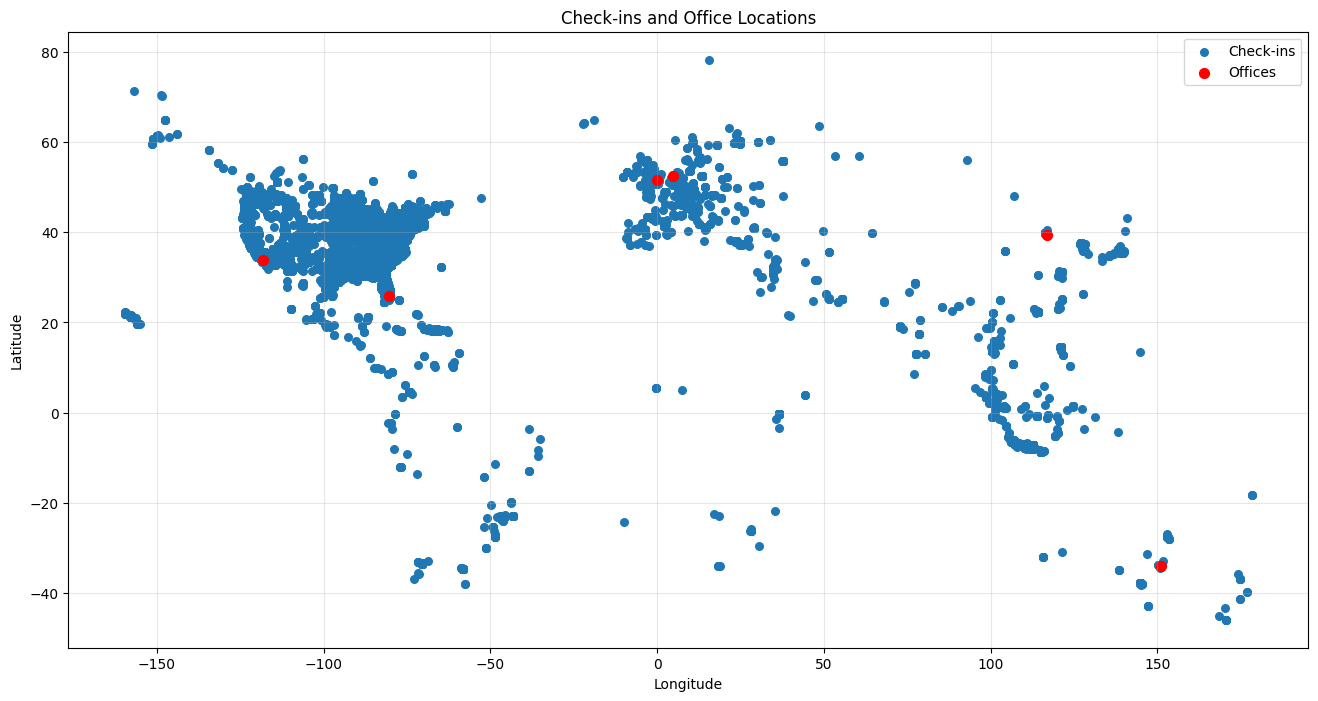

In [ ]:
plt.figure(figsize=(16, 8))
plt.scatter(X_adv[:, 0], X_adv[:, 1], s=30, label='Check-ins')
plt.scatter(offices[:, 0], offices[:, 1], color='red', s=50, label='Offices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Check-ins and Office Locations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Видно, что больше всего чекинов приходится на США и Европу. Скорее всего, в этих местах как раз и концетрируются основные клиенты круизного агенства. Будем держать эту особенность данных в голове и осозновать, что скорее всего, оптимальные точки для рекламных щитов будут именно в этих регионах.

Пришло время разбивать чекины на однородные группы. Будем делать это с помощью разных алгоритмов кластеризации. При подсчете расстояний будем пренебрегать тем, что Земля круглая, так как в точках, расположенных близко друг к другу погрешность мала, а в остальных точках значение достаточно велико, чтобы не повлиять на кластеризацию или сортировку.

# 1. K-Means

Алгоритм K-Means можно схематично представить следующим образом:

1. Инициализируем центры кластеров случайным образом (при этом заранее задаётся число кластеров $K$).
2. Каждую точку данных относим к кластеру с ближайшим центром.
3. Пересчитываем центры кластеров как центр масс всех точек, принадлежащих соответствующему кластеру.
4. Повторяем шаги 2-3 до тех пор, пока изменение центров кластеров не станет пренебрежимо малым.

Давайте посмотрим, как этот алгоритм работает на простых игрушечных данных.

In [ ]:
from sklearn.cluster import KMeans

np.random.seed(123)

# Сгенерируем игрушечные данные - стандартное нормальное распределение сконцентрированное около разных центров
X1 = np.random.randn(100, 2)
X2 = np.random.randn(100, 2) - np.array([10, 1])
X3 = np.random.randn(100, 2) - np.array([1, 10])

X = np.vstack((X1, X2, X3))

# Истинные метки кластеров
y = np.array([1] * 100 + [2] * 100 + [3] * 100)

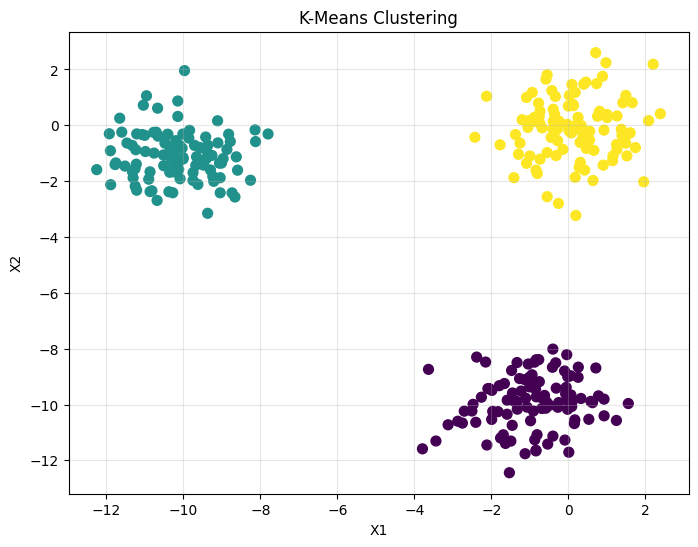

In [ ]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=123)
k_means.fit(X)
clusters = k_means.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('K-Means Clustering')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True, alpha=0.3)
plt.show()

Посмотрим что будет происходить если мы не угадали с числом кластеров.

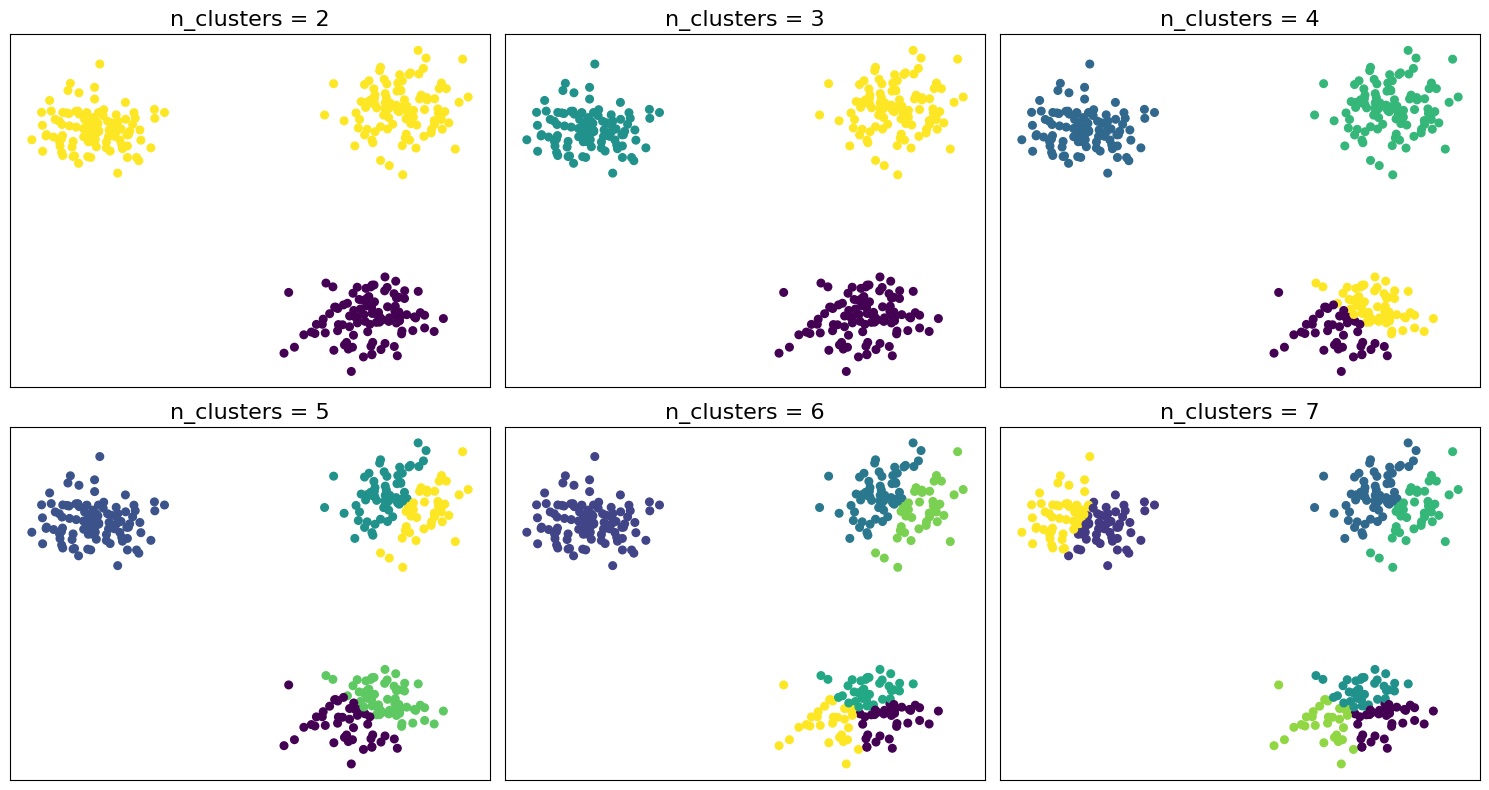

In [ ]:
plt.figure(figsize=(15, 8))

for n_c in range(2, 8):
    k_means = KMeans(n_clusters=n_c, random_state=123)
    k_means.fit(X)
    clusters = k_means.predict(X)

    plt.subplot(2, 3, n_c - 1)
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=30)
    plt.title(f'n_clusters = {n_c}', fontsize=16)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


- Один из основных недостатков K-Means - случайная инициализация центров кластеров, что может приводить к различным результатам кластеризации при повторных запусках.
- Главным достоинством алгоритма является высокая скорость: на каждой итерации требуется пересчёт лишь расстояний до центров кластеров.
- Как видно, K-Means обязательно присваивает каждую точку какому-либо кластеру и, как большинство алгоритмов кластеризации, сильно зависит от заранее заданного числа кластеров. Число кластеров можно подбирать, однако при этом могут возникнуть определённые сложности.


#### **Метод локтя**

В отличие от задач классификации или регрессии, в кластеризации сложнее выбрать критерий, который позволял бы напрямую формулировать задачу как задачу оптимизации. В случае K-Means часто используется следующий критерий - сумма квадратов расстояний точек до центроидов соответствующих кластеров:

$$
J(C) = \sum_{k=1}^K \sum_{i \in C_k} \| x_i - \mu_k \|^2 \rightarrow \min_C,
$$

где $C$ - множество кластеров мощности $K$, а $\mu_k$ - центроид кластера $C_k$.

**Здравый смысл здесь такой:** мы хотим, чтобы точки располагались плотно вокруг центров своих кластеров. Однако есть проблема: минимальное значение функционала достигается, если каждый кластер состоит из одной точки, то есть количество кластеров равно числу точек.

Для выбора числа кластеров часто используют эвристику: выбирают такое $K$, начиная с которого значение $J(C)$ перестаёт существенно уменьшаться. Более формально это можно записать как:

$$
Q(k) = \frac{|J(C_k) - J(C_{k+1})|}{|J(C_{k-1}) - J(C_k)|} \to \min_{k}.
$$

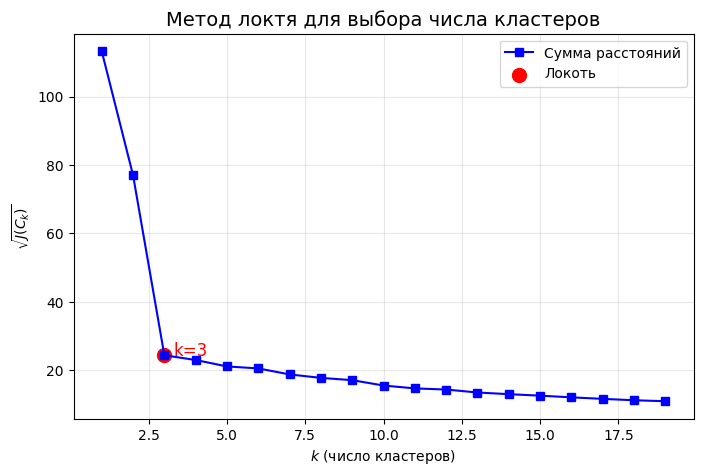

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

rg = range(1, 20)
inertia = []

for k in rg:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertia.append(np.sqrt(kmeans.inertia_))

plt.figure(figsize=(8, 5))
plt.plot(rg, inertia, marker='s', linestyle='-', color='b', label='Сумма расстояний')

# Отметим локоть
elbow_k = 3
plt.scatter(elbow_k, inertia[elbow_k - 1], color='red', s=100, label='Локоть')
plt.text(elbow_k + 0.3, inertia[elbow_k - 1], f'k={elbow_k}', color='red', fontsize=12)

plt.xlabel(r'$k$ (число кластеров)')
plt.ylabel(r'$\sqrt{J(C_k)}$')
plt.title('Метод локтя для выбора числа кластеров', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Для нашего примера трёх кластеров оказывается достаточно.

Существует множество других методов для автоматического выбора числа кластеров. Например, можно использовать вероятностный подход, при котором число кластеров подбирается автоматически, что по сути очень похоже на EM-алгоритм с автоматическим определением числа компонент.

Пожалуй наиболее известным (и популярным) методом автоматического подбора числа кластеров $K$ является *метод Силуэта*

#### **Метод Силуэта (Silhouette Method)**

Метод силуэта оценивает **насколько хорошо каждый объект вписан в свой кластер**.

Для каждой точки *i* вычисляются два расстояния:

- $a(i)$ - среднее расстояние от точки $i$ до всех других точек в её кластере
- $b(i)$ - среднее расстояние от точки $i$ до всех точек в ближайшем соседнем кластере

После этого считается коэффициент силуэта:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Затем, для каждой точки есть 3 вариант:
- $s(i)$ близко к $1$ - точка хорошо вписана в свой кластер  
- $s(i)$ около $0$ - точка лежит на границе кластеров  
- $s(i)$ близко к $-1$ - точка, вероятно, ошибочно отнесена к кластеру

Среднее значение всех $s(i)$ даёт оценку качества кластеризации.



#### **Как выбрать параметр $K$?**

Обучаем K-Means при разных значениях параметра $K$ и считаем средний коэффициент силуэта.  
Оптимальное $K$ - то, при котором этот показатель максимален.

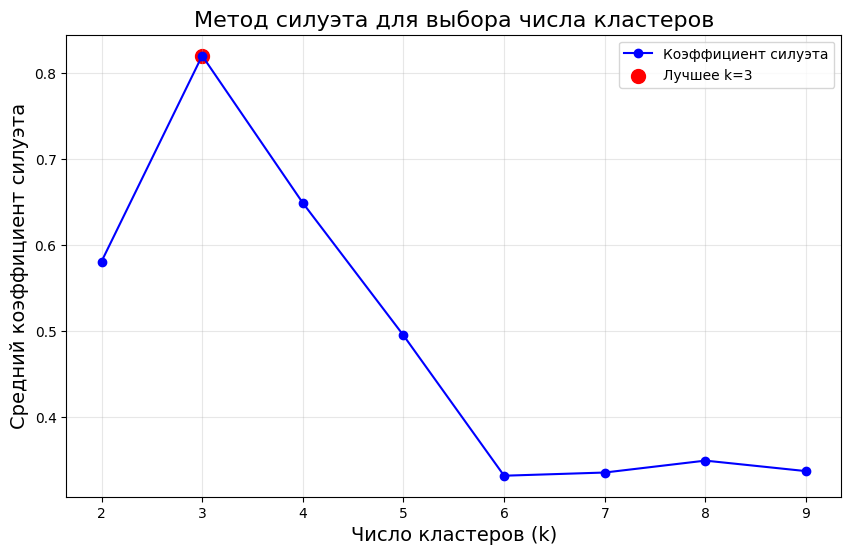

Оптимальное число кластеров по методу силуэта: k = 3


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Диапазон возможных значений K
K_range = range(2, 10)

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Находим лучший K
best_k = K_range[np.argmax(silhouette_scores)]

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', color='b', label='Коэффициент силуэта')
plt.scatter(best_k, max(silhouette_scores), color='red', s=100, label=f'Лучшее k={best_k}')
plt.title('Метод силуэта для выбора числа кластеров', fontsize=16)
plt.xlabel('Число кластеров (k)', fontsize=14)
plt.ylabel('Средний коэффициент силуэта', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Оптимальное число кластеров по методу силуэта: k = {best_k}")


Как можно видеть, метод силуэта выбрал в качестве оптимального количества кластеров $K = 3$, что соответствует нашим ожиданиям

**Преимущества метода:**

- Не требует визуального подбора или эвристических правил  
- Даёт количественную метрику качества кластеризации  
- Работает для разных типов данных и расстояний  

**Недостатки метода**

- Медленный на больших выборках (нужно считать попарные расстояния)  
- Может быть неустойчив к шуму и выбросам  


__Вернёмся к рекламе.__ Попробуем запустить алгоритм с $50$-ю кластерами.

In [ ]:
%%time
from sklearn.cluster import KMeans

kmean_model = KMeans(n_clusters=50, random_state=123)
kmean_model.fit(X_adv)

centers = kmean_model.cluster_centers_
labels = kmean_model.labels_

CPU times: user 646 ms, sys: 1.88 ms, total: 648 ms
Wall time: 378 ms


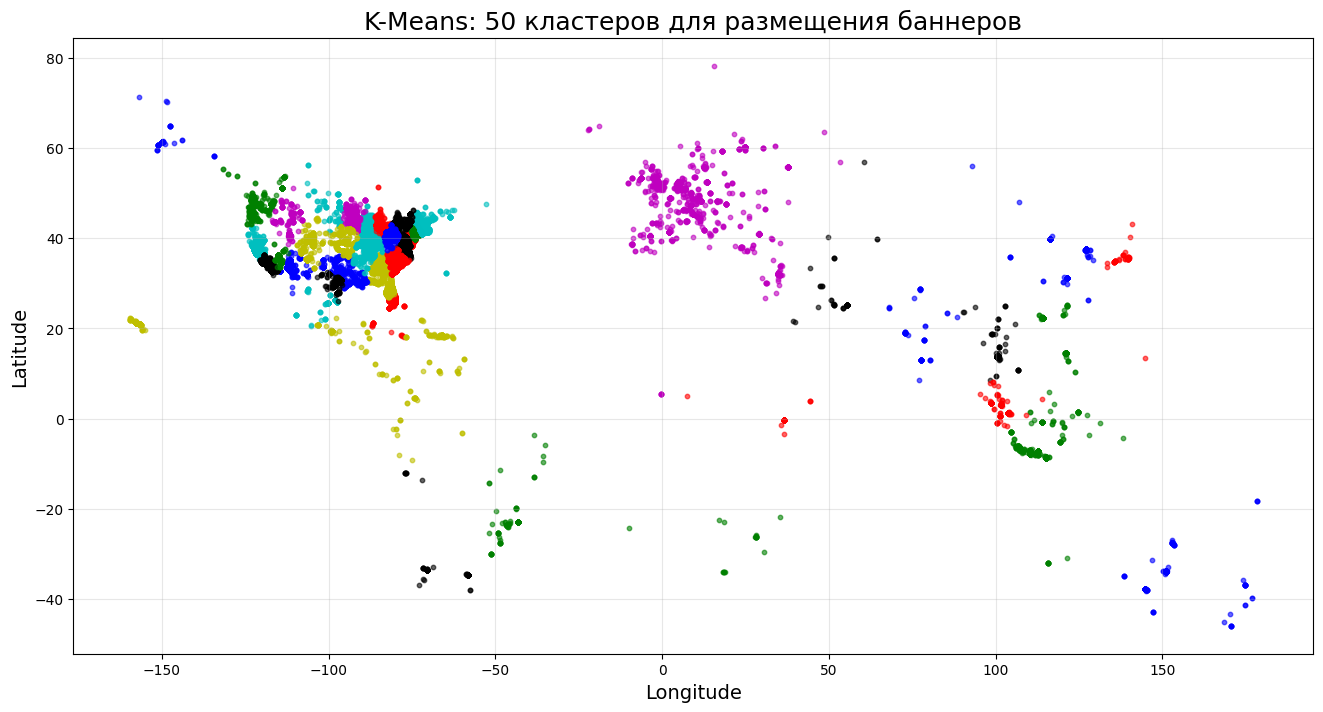

In [ ]:
from itertools import cycle

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

plt.figure(figsize=(16, 8))

# Цвета для кластеров
colors = cycle('bgrcmykbgrcmykbgrcmykbgrcmyk')

for k, col in zip(range(n_clusters_), colors):
    my_members = labels == k
    center = centers[k]

    # Наносим точки кластера на график
    plt.scatter(X_adv[my_members, 0], X_adv[my_members, 1], c=col, s=10, alpha=0.6)

plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.title('K-Means: 50 кластеров для размещения баннеров', fontsize=18)
plt.grid(True, alpha=0.3)
plt.show()


Можно попытаться подобрать оптимальное число кластеров с помощью метода локтя, который мы рассматривали ранее. Однако в данном случае этот подход не даст однозначного результата: кривая будет плавно убывать по мере увеличения числа кластеров, без явного "локтя".

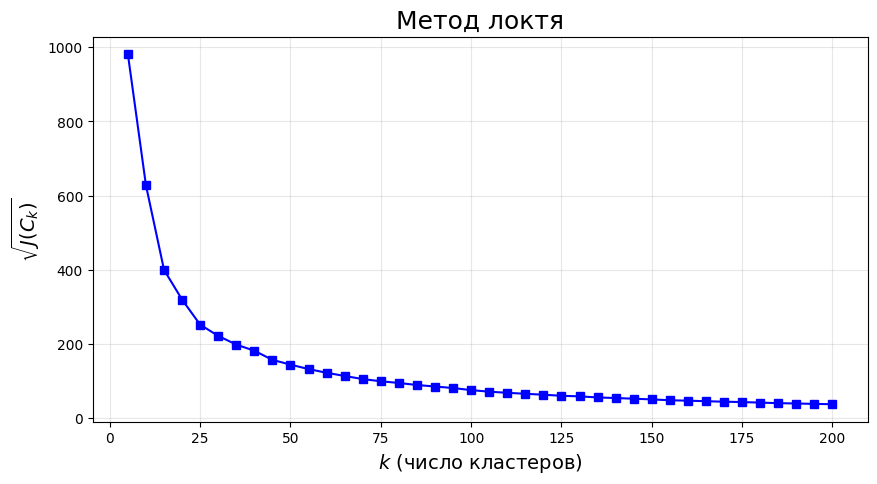

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Пробегаем по числу кластеров от 5 до 200 с шагом 5
rg = range(5, 205, 5)
inertia = []

# Берём подвыборку для ускорения расчётов
X_smpl = X_adv[:10000]

for k in rg:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_smpl)
    inertia.append(np.sqrt(kmeans.inertia_))

plt.figure(figsize=(10, 5))
plt.plot(rg, inertia, marker='s', linestyle='-', color='b')
plt.xlabel('$k$ (число кластеров)', fontsize=14)
plt.ylabel(r'$\sqrt{J(C_k)}$', fontsize=14)
plt.title('Метод локтя', fontsize=18)
plt.grid(True, alpha=0.3)
plt.show()


Как мы видим, характерного "локтя" в данном случае нет.

Хотя визуально видно, что существенное убывание $\sqrt{J (C_k)}$ происходит в районе $k \in [20, 30]$

Какие особенности алоритма мы видим на нашей задаче?

- Судя по всему, кластеры выстраиваются в соотвествии с границами стран или штатов, это не очень хорошо, непонятно как можно поставить рекламный щит в середине страны.
- Кластеры оказываются разного размера, а нам хотелось бы, чтобы для каждого банера, по площади, кластеры были одинаковыми, так как хочется одинаковой видимости, а не один банер на всю Францию с непонятно какой видимостью.

__Судя по всему, нам нужен алгоритм, который формирует кластеры в рамках какой-то заранее заданной окрестности.__

Отдельно отметим, что есть вариация k-medians, которая вместо центров кластеров вычисляет "центроиды", то есть при вычислении центров кластеров использует медиану вместо среднего. Что позволяет алгоритму стать более устойчивым к выбросам.

# 2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN - это алгоритм кластеризации, основанный на плотности. Он группирует объекты, которые находятся в областях высокой плотности, и помечает как выбросы объекты, расположенные в разрежённых областях (чьи ближайшие соседи находятся далеко).  

У алгоритма есть два основных гиперпараметра:

- `eps` - радиус окрестности, в пределах которого рассматриваются соседи точки;
- `min_samples` - минимальное число соседей в этой окрестности, необходимое для того, чтобы точка считалась «ядром» кластера.

Все точки делятся на основные точки, достижимые по плотности точки и выбросы следующим образом:

- Точка $p$ является __основной точкой (ядром),__ если по меньшей мере `min_samples` точек находятся на расстоянии, не превосходящем `eps` до неё. Говорят, что эти точки достижимы прямо из $p$.
- Точка $q$ __прямо достижима__ из $p$, если точка $q$ находится на расстоянии, не большем `eps` , от точки $p$ и $p$ должна быть основной точкой.
- Точка $q$ __достижима__ из $p$, если имеется путь $p_1,…,p_n$ где $p_1=p$ и $p_n=q$, а каждая точка $p_{i+1}$ достижима прямо из $p_i$ (все точки на пути должны быть основными, за исключением $q$)
- Все точки, не достижимые из основных точек, считаются __выбросами.__
- Если $p$ является основной точкой, то она формирует кластер вместе со всеми точками (основными или неосновными), достижимые из этой точки. Каждый кластер содержит по меньшей мере одну основную точку. Неосновные точки могут быть частью кластера, но они формируют его «край», поскольку не могут быть использованы для достижения других точек.

На диаграмме ниже `min_samples = 4`.  Точка $A$ и другие красные точки являются основными точками, поскольку область с радиусом `eps` , окружающая эти точки, содержит по меньшей мере 4 точки (включая саму точку). Поскольку все они достижимы друг из друга, точки образуют один кластер. Точки $B$ и $C$ основными не являются, но достижимы из $A$ (через другие основные точки), и также принадлежат кластеру. Точка $N$ является шумовой.

<p><a href="https://commons.wikimedia.org/wiki/File:DBSCAN-Illustration.svg#/media/Файл:DBSCAN-Illustration.svg"><img src="https://upload.wikimedia.org/wikipedia/commons/a/af/DBSCAN-Illustration.svg" alt="DBSCAN-Illustration.svg" width="450" height="450"> </a><br>Автор: <a href="//commons.wikimedia.org/wiki/User:Chire" title="User:Chire">Chire</a> &mdash; <span class="int-own-work" lang="ru">собственная работа</span>, <a href="https://creativecommons.org/licenses/by-sa/3.0" title="Creative Commons Attribution-Share Alike 3.0">CC BY-SA 3.0</a>

Посмотрим на результаты кластеризации при разном выборе параметра `eps` и `min_samples` на нашем игрушечном примере.

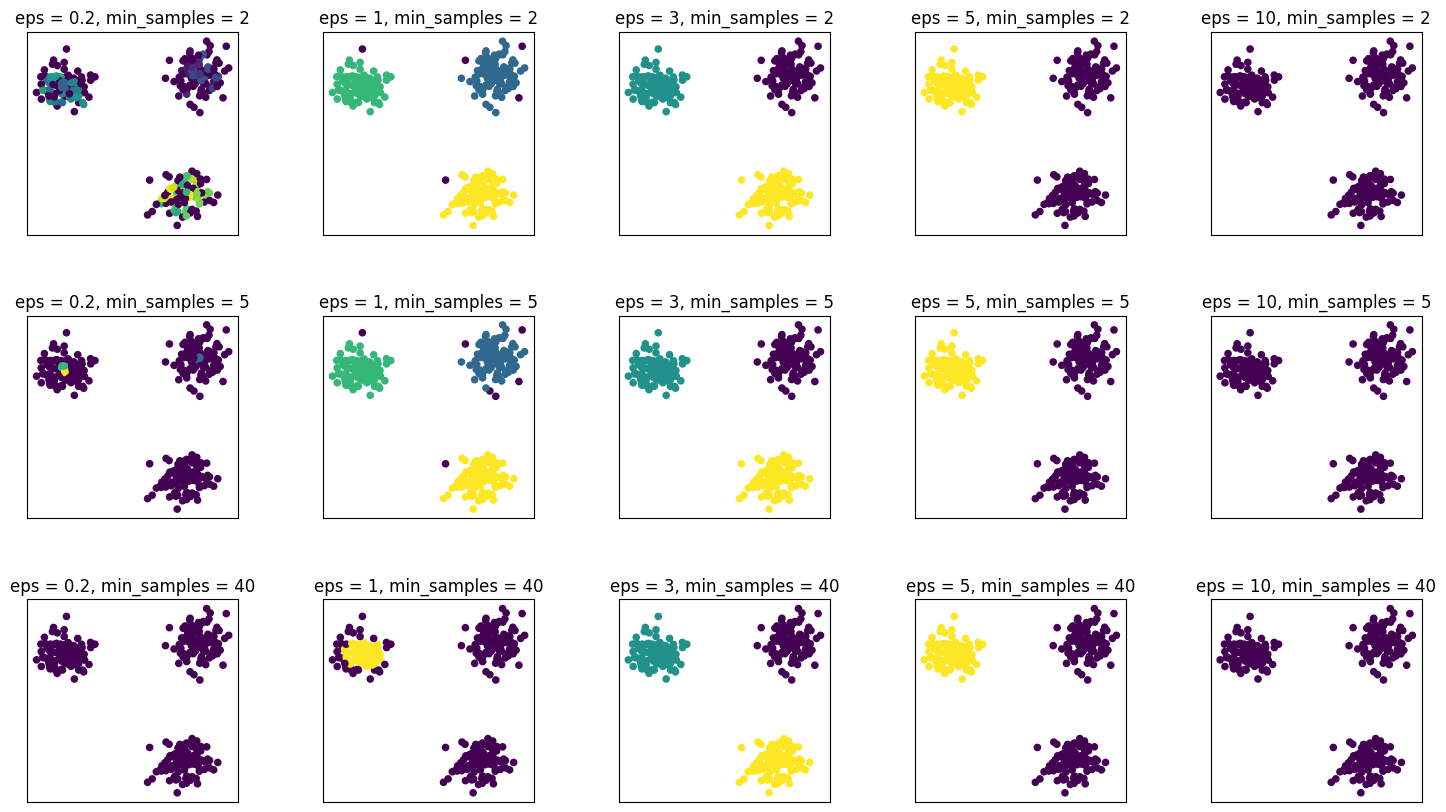

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

smpl = [2, 5, 40]
eps = [0.2, 1, 3, 5, 10]

fig, axs = plt.subplots(len(smpl), len(eps), figsize=(18, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, min_s in enumerate(smpl):
    for j, e in enumerate(eps):
        dbscan = DBSCAN(eps=e, min_samples=min_s)
        clusters = dbscan.fit_predict(X)

        axs[i, j].scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=20)
        axs[i, j].set_title(f'eps = {e}, min_samples = {min_s}')
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])

plt.show()

Метод умеет хорошо искать кластеры сложной формы. При этом он довольно сложный в настройке – очень чувствителен к параметру ”плотности” `eps`. Давайте попробуем поперибирать значение `eps` и посмотрим как меняется число кластеров и шумовых наблюдений.

In [ ]:
# Изначально считаем все наблюдения аномальными
outlier_percentage = 1.0

num_clusters = []
anomaly_percentage = []

# Начнем с маленького eps и постепенно увеличиваем
eps = 0.05
eps_history = [eps]

while outlier_percentage > 0.1:
    model = DBSCAN(eps=eps).fit(X)
    labels = model.labels_

    num_clusters.append(len(np.unique(labels)) - 1)

    # Помечаем выбросы как 1, остальные как 0
    labels_binary = np.array([1 if label == -1 else 0 for label in labels])

    outlier_percentage = np.mean(labels_binary)
    anomaly_percentage.append(outlier_percentage)

    eps += 0.05
    eps_history.append(eps)


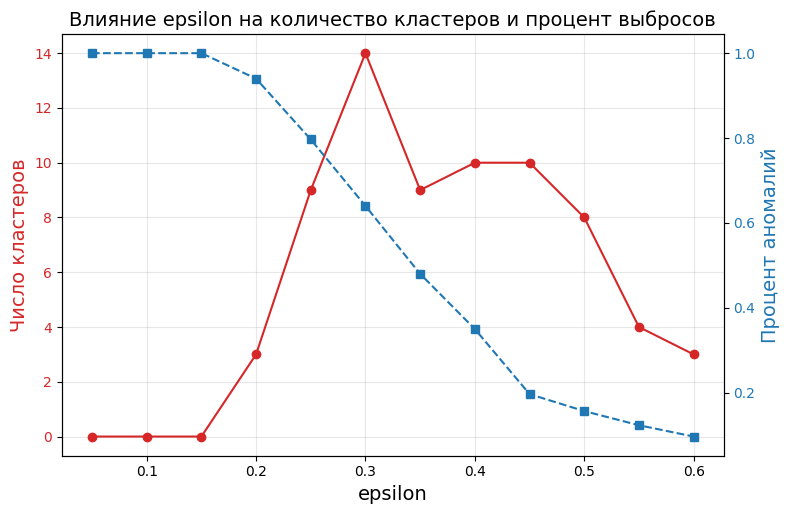

In [ ]:
iterations = eps_history[:-1]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Левая ось: число кластеров
color = 'tab:red'
ax1.set_xlabel('epsilon', fontsize=14)
ax1.set_ylabel('Число кластеров', color=color, fontsize=14)
ax1.plot(iterations, num_clusters, color=color, marker='o', linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Правая ось: процент аномалий
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Процент аномалий', color=color, fontsize=14)
ax2.plot(iterations, anomaly_percentage, color=color, marker='s', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Влияние epsilon на количество кластеров и процент выбросов', fontsize=14)
plt.show()


__Вернёмся к рекламе.__

DBSCAN понимает где какая плотность точек. Попробуем запустить его на наших данных. Подумаем о том, какие параметры выбрать.

- $0.1$ градус это примерно $5-10$ км в средних широтах
- Параметр `eps` отвечает за максимальную дистанцию между двумя точками в рамках одного кластера. Было бы неплохо, если бы внутри кластера точки находились не очень далеко друг от друга, это позволит выделить наиболее плотные сгустки. Если поставим $0.01$, то мы разрешим расстояние между точками $500$ метров - $1$ км в средних широтах. Наверное, можно отнести такие чекины к одному туристическому объекту.
- Параметр `min_samples`, минимальное число чекинов в кластере, давайте возьмём $10$, чтобы избавиться от маргинальных кластеров по 1-2-3 наблюдения.

In [ ]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(eps=0.01, min_samples=10)
dbscan_model.fit(X_adv)

labels = dbscan_model.labels_

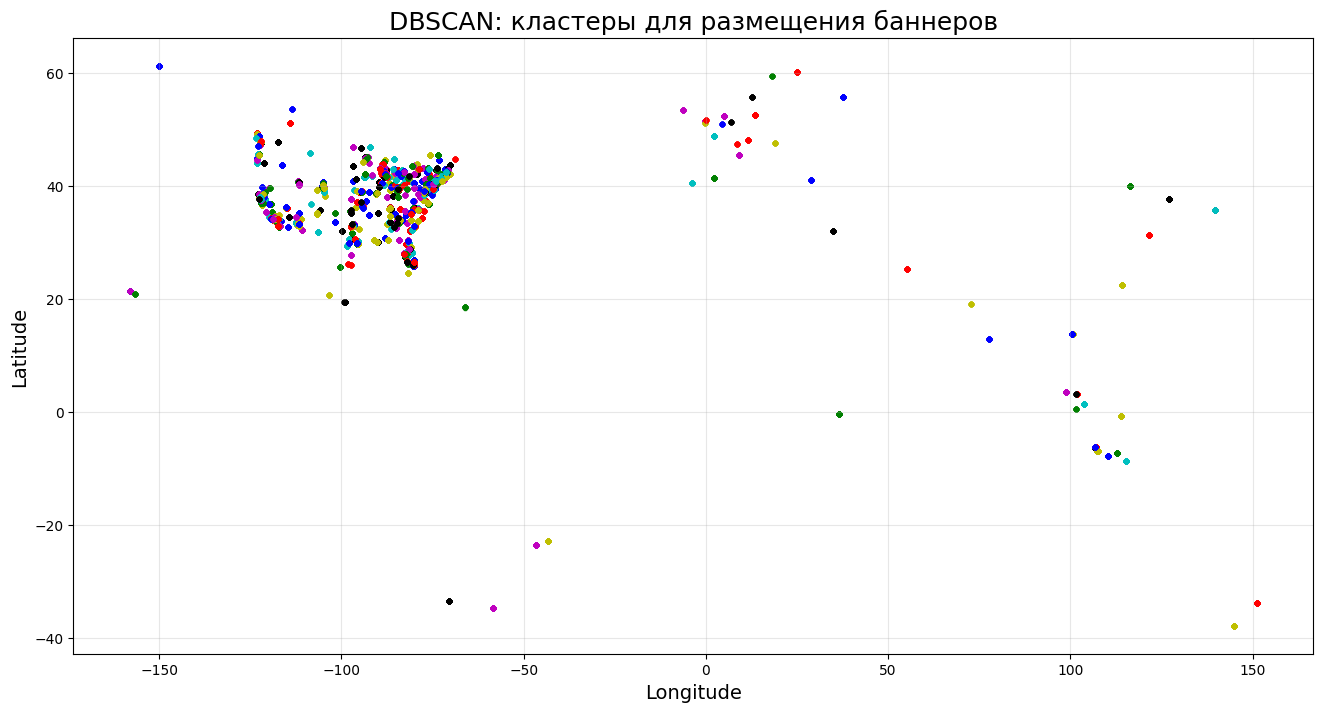

In [ ]:
labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

plt.figure(figsize=(16, 8))
colors = cycle('bgrcmykbgrcmykbgrcmykbgrcmyk')

for k, col in zip(range(n_clusters_), colors):
    my_members = labels == k
    plt.scatter(X_adv[my_members, 0], X_adv[my_members, 1], c=col, s=10, alpha=0.6)

plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.title('DBSCAN: кластеры для размещения баннеров', fontsize=18)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
n_clusters_

1108

Меткой $-1$ отмечаются шумовые точки, их получается около $15\%$.

In [ ]:
np.sum(labels == -1) # меткой -1 отмечаются шумовые точки

np.int64(14968)

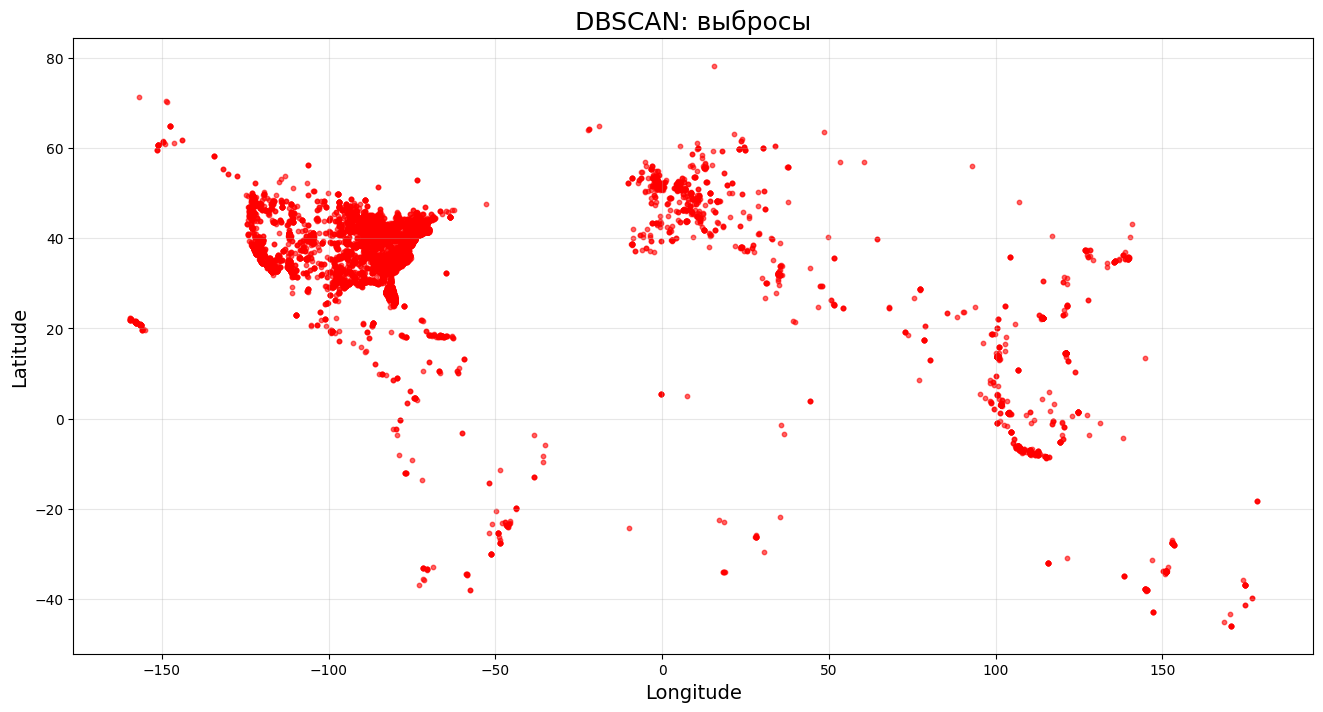

In [ ]:
# Выбираем все точки, помеченные как выбросы (-1)
outliers = (labels == -1)

plt.figure(figsize=(16, 8))
plt.scatter(X_adv[outliers, 0], X_adv[outliers, 1], c='red', s=10, alpha=0.6)
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.title('DBSCAN: выбросы', fontsize=18)
plt.grid(True, alpha=0.3)
plt.show()


Помотрим на размеры других кластеров.

In [ ]:
from collections import Counter
cluster_counts = Counter(labels)
cluster_counts.most_common(20)

[(np.int64(-1), 14968),
 (np.int64(15), 6091),
 (np.int64(3), 4926),
 (np.int64(22), 3890),
 (np.int64(2), 2746),
 (np.int64(1), 2070),
 (np.int64(36), 2024),
 (np.int64(70), 1485),
 (np.int64(25), 1440),
 (np.int64(49), 1257),
 (np.int64(50), 1163),
 (np.int64(78), 1130),
 (np.int64(12), 1086),
 (np.int64(6), 1080),
 (np.int64(30), 1063),
 (np.int64(45), 1050),
 (np.int64(40), 1046),
 (np.int64(11), 1032),
 (np.int64(33), 1020),
 (np.int64(5), 964)]

- Из-за логичного подбора параметров кластеры получилсь довольно компактными, а не размером в страну.
- Кластеры очень разные по размерам.
- Кластеры могут быть причудливой формы. Например, вытянутыми, как бананы. Из-за этого сложно понять где у него центр и куда пихать щит, в отличие от выпуклых кластеров в k-means.

**Вывод:** Для решения нашей задачи DBSCAN не очень подходит.

# 3. Иерархическая кластеризация

Рассмотрим ещё один алгоритм - иерархическую кластеризацию. Существует два подхода:

- **Агломеративная**, при которой на каждой итерации два наименьших кластера объединяются в один;
- **Дивизивная**, при которой на каждой итерации один кластер делится на два более мелких.

Мы сосредоточимся на **агломеративном подходе**:

1. Инициализация: каждая точка считается отдельным кластером. Для выборки из $N$ объектов на первой итерации получаем $N$ кластеров. Алгоритм также требует выбора метрики расстояния между кластерами; популярным выбором является расстояние Уорда.
2. На каждой итерации объединяются два кластера, расстояние между которыми минимально согласно выбранной метрике. Таким образом, объединяются наиболее похожие кластеры.
3. Процесс повторяется до тех пор, пока все точки не объединятся в один кластер.

Преимущество этого подхода заключается в том, что после завершения процедуры можно выбрать любое количество кластеров, просто остановившись на нужном уровне дендрограммы. Кроме того, агломеративная кластеризация менее чувствительна к выбору метрики между точками, в отличие от некоторых других алгоритмов.

Для визуализации иерархической кластеризации удобно использовать **дендрограммы**, где высота соединения кластеров соответствует расстоянию, на котором они объединяются на данном этапе.

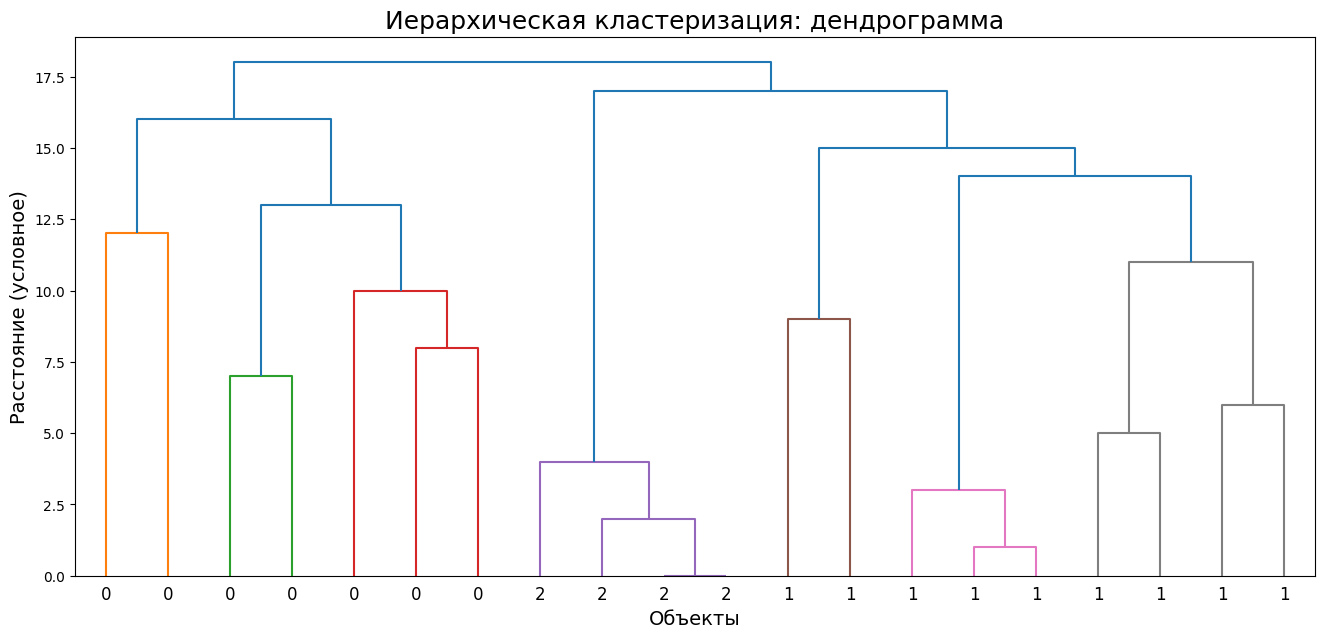

In [ ]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt

def plot_dendrogram(model, **kwargs):
    """Функция для построения дендрограммы из модели AgglomerativeClustering"""
    # Дочерние кластеры
    children = model.children_

    # Расстояния между каждым уровнем (используем равномерные для визуализации)
    distance = np.arange(children.shape[0])

    # Количество объектов на каждом уровне
    no_of_observations = np.arange(2, children.shape[0] + 2)

    # Формируем матрицу linkage
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)

    # Строим дендрограмму
    dendrogram(linkage_matrix, **kwargs)

# Снова ирисы
iris = load_iris()
X = iris.data[:20]

model = AgglomerativeClustering(n_clusters=3)
model = model.fit(X)

plt.figure(figsize=(16, 7))
plot_dendrogram(model, labels=model.labels_)
plt.title('Иерархическая кластеризация: дендрограмма', fontsize=18)
plt.xlabel('Объекты', fontsize=14)
plt.ylabel('Расстояние (условное)', fontsize=14)
plt.show()

Если нет каких-то специализированных условий (например известно что кластеров должно быть не более $K$), то число кластеров можно выбирать по резкому скачку дендрограммы. *Кроме того в некоторых задачах важно понимать для чего делается кластеризация и доменную область задачи, исходя из этого можно сильно сократить искомое количество кластеров*.  

Также в иерархическую кластеризацию можно передавать дополнительную (например априорную) информацию вида I-я и J-я точки "похожи". Это задается через матрицу связей.

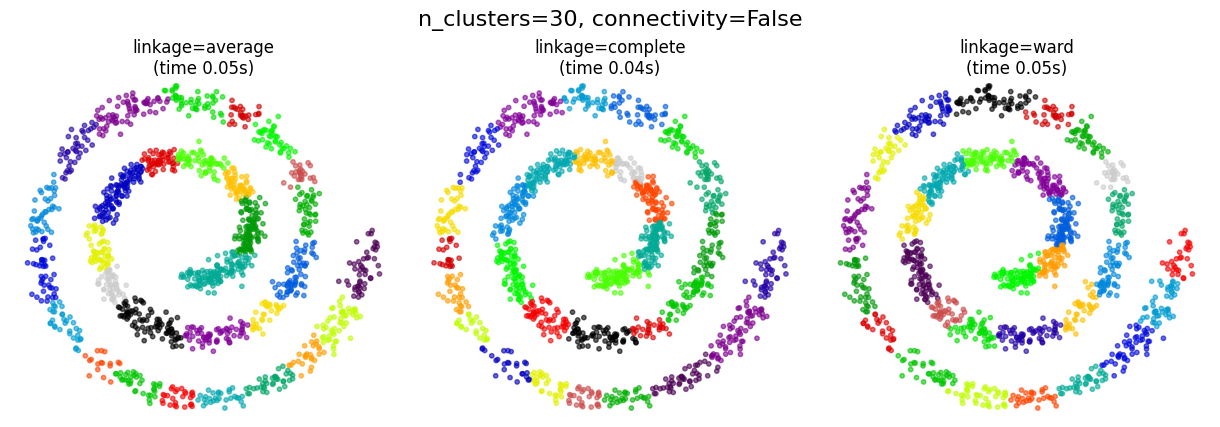

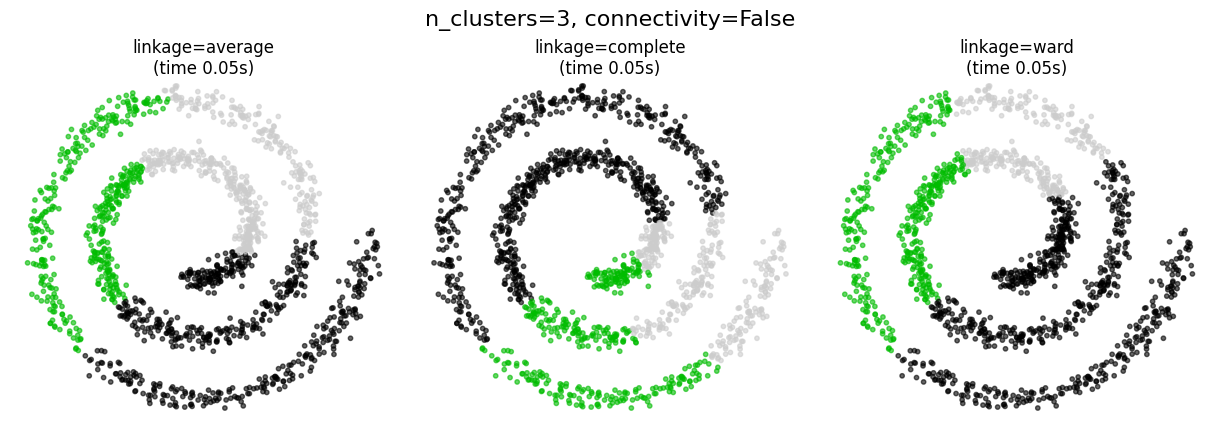

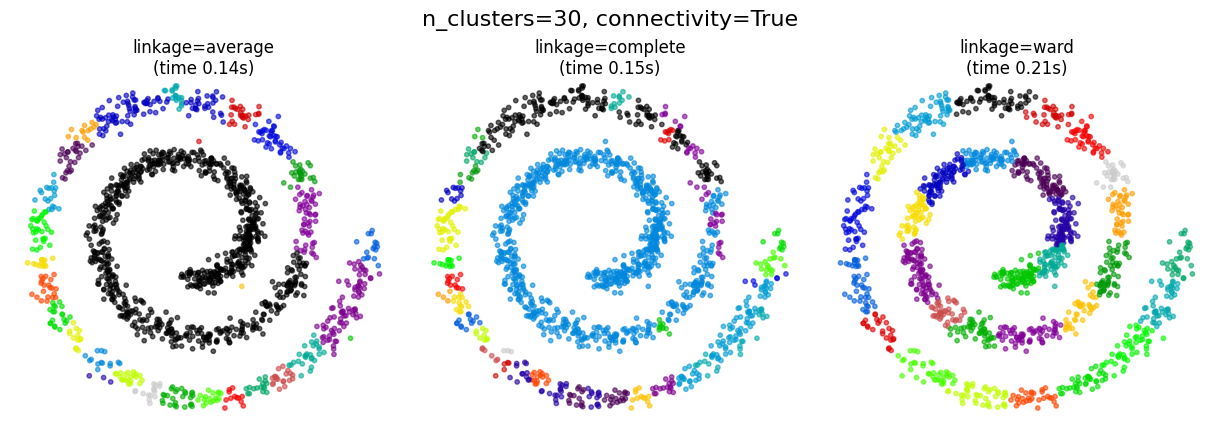

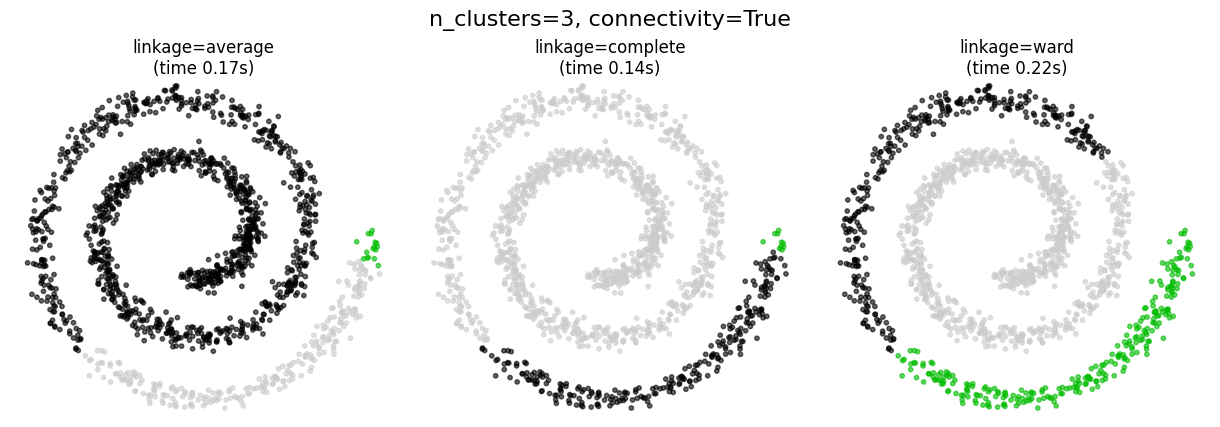

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph

# Генерация синтетических данных "спираль"
n_samples = 1500
np.random.seed(0)
t = 1.5 * np.pi * (1 + 3 * np.random.rand(1, n_samples))
x = t * np.cos(t)
y = t * np.sin(t)

X = np.concatenate((x, y))
X += 0.7 * np.random.randn(2, n_samples)
X = X.T

# Создание графа ближайших соседей для учета локальной связности
# Большее число соседей дает более однородные кластеры, но увеличивает время вычислений
knn_graph = kneighbors_graph(X, n_neighbors=30, include_self=False)

for connectivity in (None, knn_graph):
    for n_clusters in (30, 3):
        fig = plt.figure(figsize=(12, 4))
        for idx, linkage in enumerate(('average', 'complete', 'ward')):
            plt.subplot(1, 3, idx + 1)

            model = AgglomerativeClustering(
                linkage=linkage,
                connectivity=connectivity,
                n_clusters=n_clusters
            )

            t0 = time.time()
            model.fit(X)
            elapsed_time = time.time() - t0

            plt.scatter(X[:, 0], X[:, 1], c=model.labels_,
                        cmap=plt.cm.nipy_spectral, s=10, alpha=0.6)
            plt.title(f'linkage={linkage}\n(time {elapsed_time:.2f}s)',
                      fontdict=dict(verticalalignment='top'))
            plt.axis('equal')
            plt.axis('off')

        plt.suptitle(f'n_clusters={n_clusters}, connectivity={connectivity is not None}', size=16, y=1.02)
        plt.subplots_adjust(bottom=0, top=0.85, wspace=0.05, left=0, right=1)


plt.show()


__Вернёмся к рекламе.__

Даже пробовать не будем для рекламы этот алгоритм. Он будет работать довольно долго из-за того, что нам придется посчитать все взаимные расстояния между точками. Сам по себе алгоритм не устранит проблемы, которые возникли выше.

# 4. Сравнение работы алгоритмов

Сгенерируем кластеры разной формы и посмотрим на результаты работы алгоритмов

Automatically created module for IPython interactive environment


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:596: UserWarning: the number of connected components of the connectivity matrix is 2 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:596: UserWarning: the number of connected components of the connectivity matrix is 78 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:596: UserWarning: the number of connected components of the connectivity matrix is 51 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:596: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to a

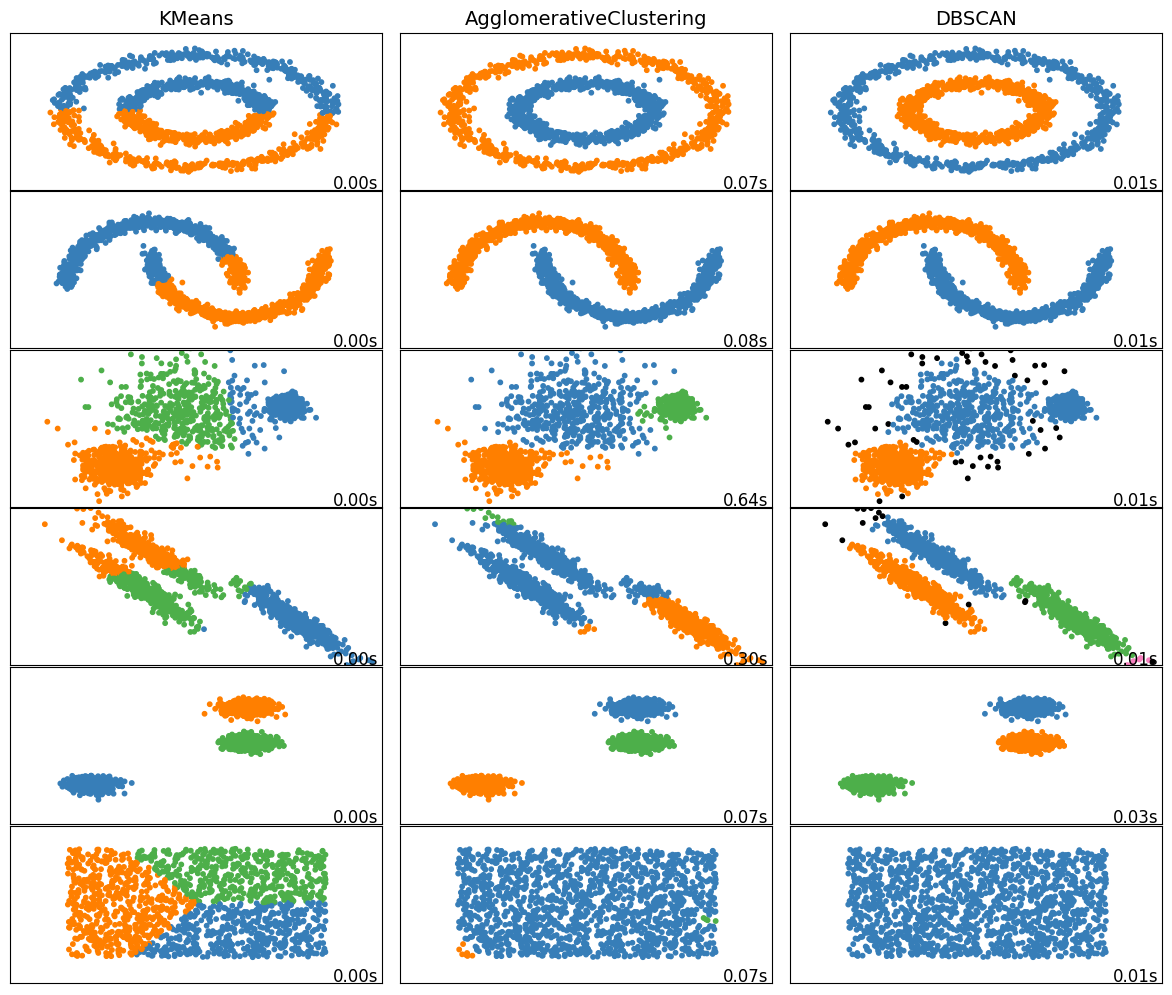

In [ ]:
print(__doc__)
import warnings

from sklearn import cluster, datasets
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

np.random.seed(0)

# генерация наборов данных
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = (np.random.rand(n_samples, 2), None)

# анизотропные данные
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# кластеры с разной дисперсией
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# параметры по умолчанию для алгоритмов
default_base = {
    'quantile': 0.3,
    'eps': 0.3,
    'damping': 0.9,
    'preference': -200,
    'n_neighbors': 10,
    'n_clusters': 3,
    'min_samples': 20,
    'xi': 0.05,
    'min_cluster_size': 0.1
}

datasets_list = [
    (noisy_circles, {'damping': 0.77, 'preference': -240, 'quantile': 0.2, 'n_clusters': 2, 'min_samples': 20, 'xi': 0.25}),
    (noisy_moons, {'damping': 0.75, 'preference': -220, 'n_clusters': 2}),
    (varied, {'eps': 0.18, 'n_neighbors': 2, 'min_samples': 5, 'xi': 0.035, 'min_cluster_size': 0.2}),
    (aniso, {'eps': 0.15, 'n_neighbors': 2, 'min_samples': 20, 'xi': 0.1, 'min_cluster_size': 0.2}),
    (blobs, {}),
    (no_structure, {})
]

plt.figure(figsize=(12, 10))
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.01, top=0.96, wspace=0.05, hspace=0.01)
plot_num = 1

for i_dataset, (dataset, algo_params) in enumerate(datasets_list):

    # обновляем параметры конкретного датасета
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset
    X = StandardScaler().fit_transform(X)

    # граф ближайших соседей для учета локальной связности
    connectivity = kneighbors_graph(X, n_neighbors=params['n_neighbors'], include_self=False)
    connectivity = 0.5 * (connectivity + connectivity.T)  # сделать симметричным

    # cоздаем объекты алгоритмов
    k_means = cluster.KMeans(n_clusters=params['n_clusters'])
    dbscan = cluster.DBSCAN(eps=params['eps'])
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average", metric="cityblock",
        n_clusters=params['n_clusters'], connectivity=connectivity
    )

    clustering_algorithms = (
        ('KMeans', k_means),
        ('AgglomerativeClustering', average_linkage),
        ('DBSCAN', dbscan)
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()
        algorithm.fit(X)
        t1 = time.time()

        # получаем метки кластеров
        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets_list), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=14)

        colors = np.array(list(islice(cycle([
            '#377eb8', '#ff7f00', '#4daf4a', '#f781bf',
            '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00'
        ]), int(max(y_pred) + 1))))
        colors = np.append(colors, ['#000000'])  # черный для выбросов

        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(.99, .01, f'{t1 - t0:.2f}s', transform=plt.gca().transAxes,
                 size=12, ha='right')
        plot_num += 1

plt.show()

# 5. Что же делать с рекламой?

Нам очень хотелось понять, куда можно поставит рекламный баннер. Мы рассмотрели три алгоритма. У каждого из них обнаружились свои недостатки:

- **Kmeans:** непонятно как подобрать число кластеров, кластеры получаются очень разных размеров
- **DBSCAN:** кластеры оказываются плотными, но очень причудливой формы и разных размеров
- **Агломеративная кластеризация:** долго работает, кластеры разных размеров

Глобальная проблема заключалась в том, что ни один из алгоритмов не мог ограничить расстояние от центра кластера до самой крайней точки. К счастью, алгоритмов кластеризации довольно много.

Для решения найшей задачи подойдет алгоритм `MeanShift`. Его описание можно посмотреть в [sklearn user guide.](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html)  В этом алгоритме можно искусственно ограничить радиус, в котором мы ищем центроиду каждого кластера с помощью специальной опции `bandwidth`. Укажем `bandwidth=0.01`, что в переводе из градусов в метры колеблется примерно от 500 метров до 1 км в средних широтах.

- Параметр `bin_seeding` делает более умную инициализацию начальных координат. Если он установлен в True, алгоритм пытается инициализировать исходные точки в тех местах, где сосредоточено много данных.
- Параметр `min_bin_freq` отвечает за минимальное число точек в кластере

In [ ]:
%%time
from sklearn.cluster import MeanShift

clt = MeanShift(bandwidth=0.01, bin_seeding=True, min_bin_freq=20)
clt.fit(X_adv)

CPU times: user 1.89 s, sys: 7.13 ms, total: 1.89 s
Wall time: 1.9 s


MeanShift(bandwidth=0.01, bin_seeding=True, min_bin_freq=20)

In [ ]:
labels = clt.labels_
centers = clt.cluster_centers_

n_clusters_ = len(centers)
n_clusters_

549

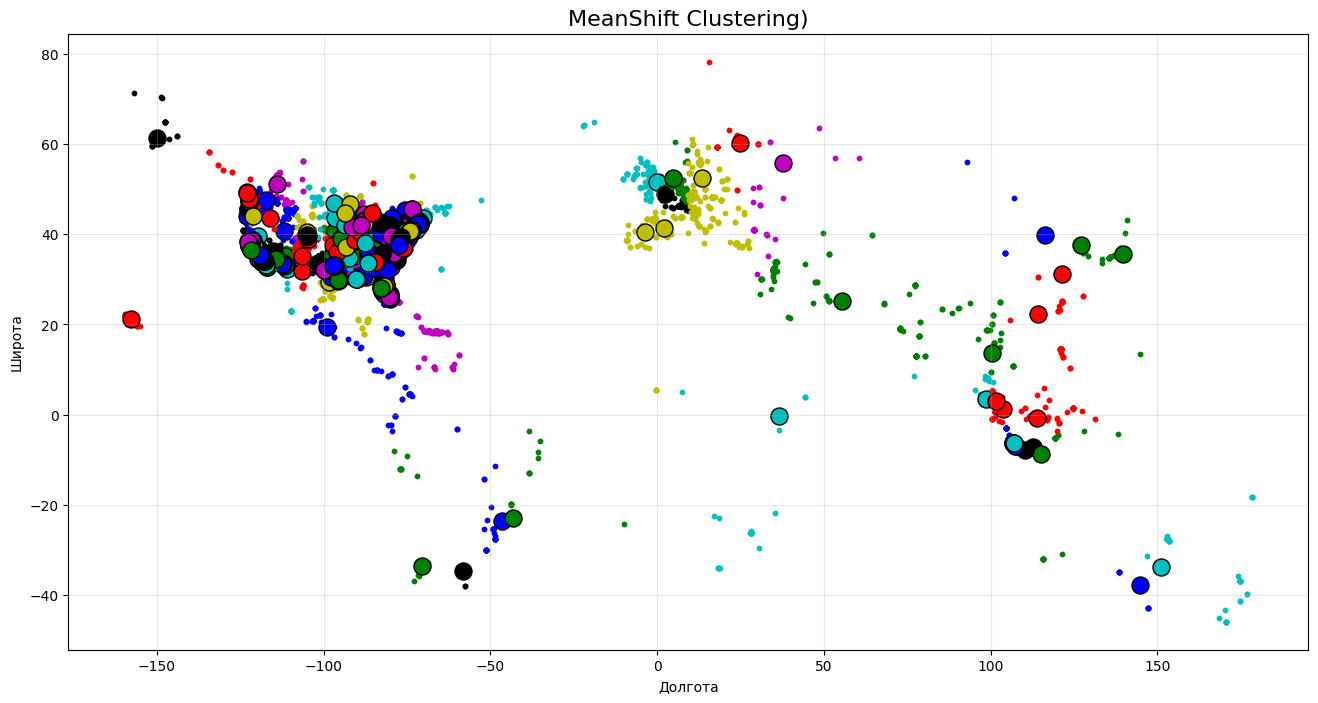

In [ ]:
plt.figure(figsize=(16,8))
colors = cycle('bgrcmykbgrcmykbgrcmykbgrcmyk')

for k, col in zip(range(n_clusters_), colors):
    my_members = labels == k
    center = centers[k]

    # Наносим точки кластера
    plt.scatter(X_adv[my_members,0], X_adv[my_members,1], c=col, s=10)

    # Выделяем центры кластеров
    plt.scatter(center[0], center[1], c=col, edgecolor='k', s=150, marker='o')

plt.title(f'MeanShift Clustering)', fontsize=16)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.grid(alpha=0.3)
plt.show()

Мы должны выбрать 20 самых близких к офисам точек. Для этого отсортируем центры кластеров по расстояниям до каждого офиса.

In [ ]:
results = [ ]
for item in offices:
    for jtem in centers:
        cur_rast = float(np.linalg.norm(jtem - item, ord=2))
        trio = (cur_rast, jtem, item)
        results.append(trio)

In [ ]:
# всего у нас есть вот столько вариантов расположить рекламные щиты
len(results)

3294

In [ ]:
results.sort() # отсортировали по расстоянию
best_20 = results[:20] # взяли 20 самых близких
best_20[:5]

[(0.009506306325582008,
  array([ 4.89242771, 52.37285747]),
  array([ 4.885084, 52.378894])),
 (0.010378706829343021,
  array([151.2111111, -33.8599722]),
  array([151.205134, -33.868457])),
 (0.050910283989965645,
  array([-0.12633096, 51.50057972]),
  array([-0.075479, 51.503016])),
 (0.06110288218605186,
  array([-118.15814667,   33.80416944]),
  array([-118.18874 ,   33.751277])),
 (0.11421928552644192,
  array([-80.2867501,  25.9756704]),
  array([-80.324116,  25.867736]))]

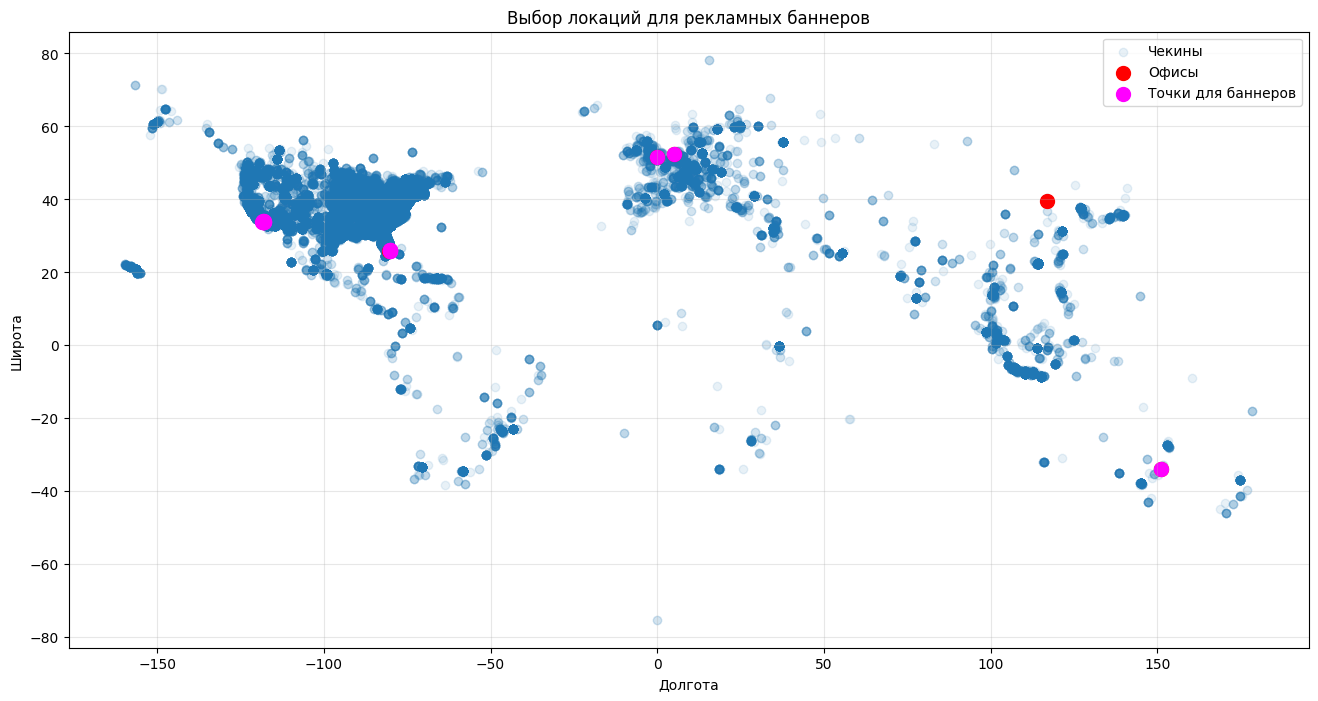

In [ ]:
coord = np.array([[item[1][0],item[1][1]] for item in best_20])

plt.figure(figsize=(16,8))

plt.scatter(df.longitude.values, df.latitude.values, alpha=0.1, label='Чекины')
plt.scatter(offices[:,0], offices[:,1], color='red', s=100, label='Офисы')
plt.scatter(coord[:,0], coord[:,1], color='magenta', s=100, label='Точки для баннеров')

plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Выбор локаций для рекламных баннеров')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Посмотрим в окрестностях какого офиса оказалась большая часть баннеров.

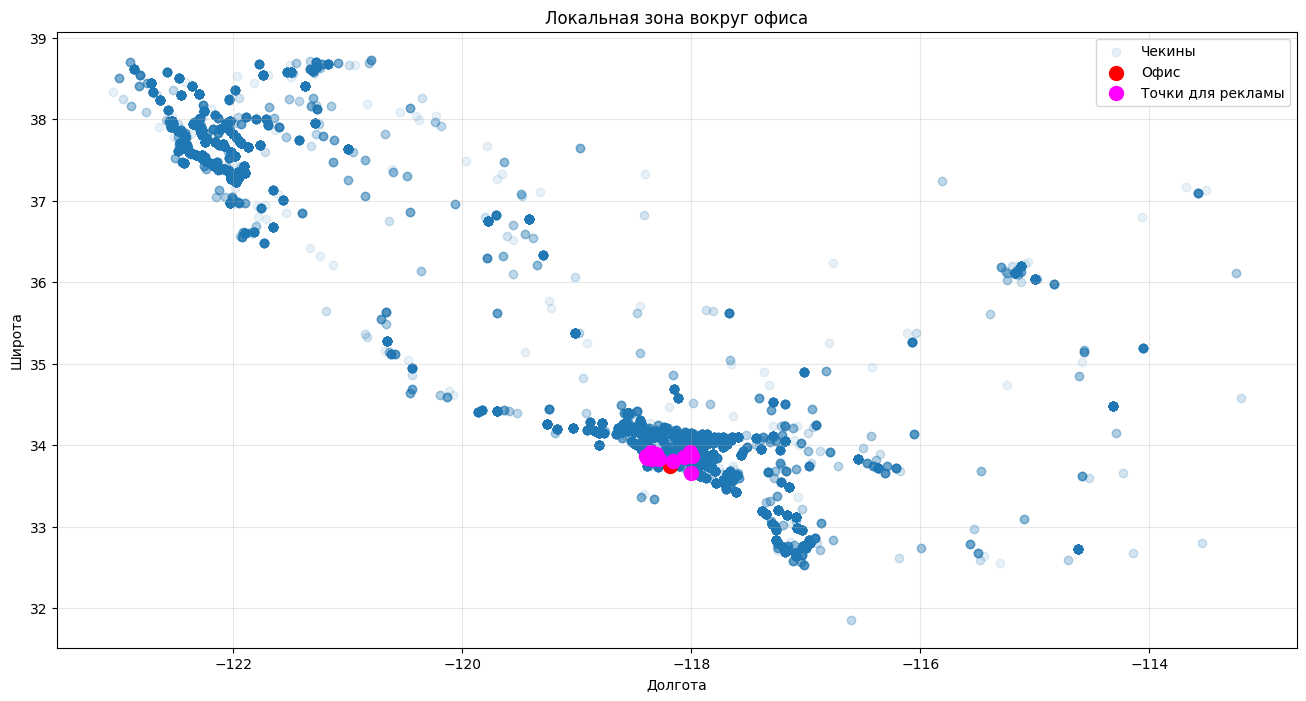

In [ ]:
l = 5
c_long = offices[0][0]
c_lat = offices[0][1]

X_int = df[(df.longitude > c_long - l) & (df.longitude < c_long + l) &
           (df.latitude > c_lat - l) & (df.latitude < c_lat + l)]

coord_int = coord[(coord[:,0] > c_long - l) & (coord[:,0] < c_long + l) &
                  (coord[:,1] > c_lat - l) & (coord[:,1] < c_lat + l)]

offices_int = offices[(offices[:,0] > c_long - l) & (offices[:,0] < c_long + l) &
                      (offices[:,1] > c_lat - l) & (offices[:,1] < c_lat + l)]

plt.figure(figsize=(16,8))
plt.scatter(X_int.longitude.values, X_int.latitude.values, alpha=0.1, label='Чекины')
plt.scatter(offices_int[:,0], offices_int[:,1], color='red', s=100, label='Офис')
plt.scatter(coord_int[:,0], coord_int[:,1], color='magenta', s=100, label='Точки для рекламы')

plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Локальная зона вокруг офиса')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Это Калифорния.

Итак, мы только что помогли выбрать круизному агенству просматриваемые и близкие к офисам точки для рекламы. В ходе решения задачи:

- Мы выслушали заказчика и поняли какие есть ограничения.
- Мы придумали откуда взять данные и как по ним найти популярные места.
- Мы нашли подходящий алгоритм кластеризации и обучили модель.
- Мы подыскали самые просматриваемые локации в окрестности офисов.

Осталось только нарисовать красивую презентацию и показать это добро "Carnival Cruise Line".

## Материалы

- [Обзор](https://scikit-learn.org/stable/modules/clustering.html) разных алгоритмов кластеризации из sklearn
- Визуализация работы [K-Means](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)
- Визуализация работы [DBSCAN](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)
- [Подробнее про разные метрики кластеризации](http://nlp.uned.es/docs/amigo2007a.pdf ) и критерии для них
- [Про разные методы кластеризации](http://www.datalaundering.com/download/mm2.pdf)
